<a href="https://colab.research.google.com/github/suparuek2405/credit-default-dl/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Exploratory Data Analysis
### UCI Credit Card Default Dataset
**Goal:** Understand the data before modeling — distributions, imbalance, correlations, and key patterns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("Imports done.")

Imports done.


In [6]:
# Upload UCI_Credit_Card.csv manually via Colab sidebar
# Files → Upload → select your CSV

df = pd.read_csv('UCI_Credit_Card.csv')
df = df.drop('ID', axis=1)
df = df.rename(columns={'default.payment.next.month': 'target'})

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Shape: (30000, 24)
Rows: 30,000  |  Columns: 24


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [7]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types ===
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
target         int64
dtype: object

=== Missing Values ===
No missing values.

=== Basic Statistics ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


In [9]:
import os
os.makedirs('results/figures', exist_ok=True)
print("Folders ready.")

Folders ready.


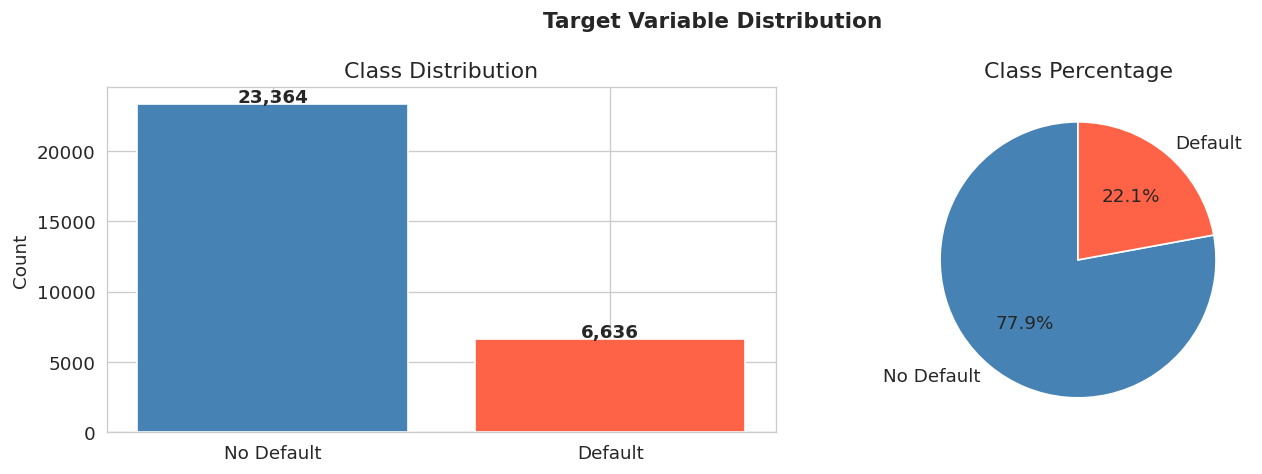


Default rate: 22.1%
Imbalance ratio: 3.5:1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['target'].value_counts()
axes[0].bar(['No Default', 'Default'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(counts.values,
            labels=['No Default', 'Default'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Percentage')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDefault rate: {df['target'].mean():.1%}")
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

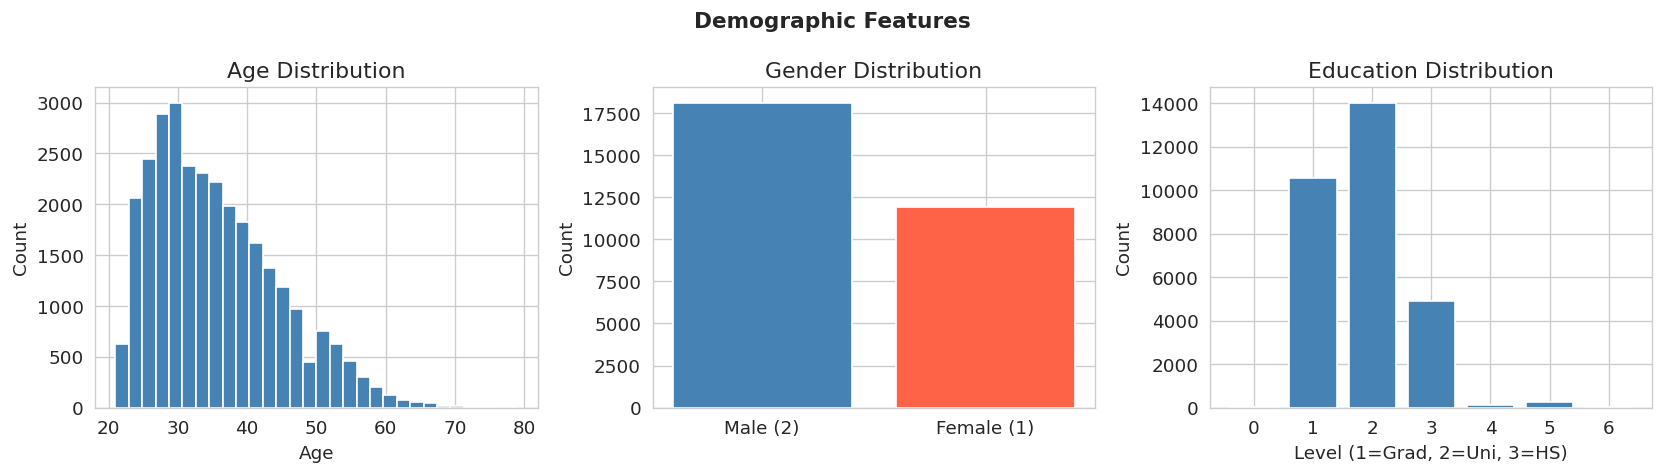

In [11]:
# Demographic features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution
axes[0].hist(df['AGE'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Sex distribution
sex_counts = df['SEX'].value_counts()
axes[1].bar(['Male (2)', 'Female (1)'],
            [sex_counts[2], sex_counts[1]],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')

# Education distribution
edu_counts = df['EDUCATION'].value_counts().sort_index()
axes[2].bar(edu_counts.index.astype(str), edu_counts.values,
            color='steelblue', edgecolor='white')
axes[2].set_title('Education Distribution')
axes[2].set_xlabel('Level (1=Grad, 2=Uni, 3=HS)')
axes[2].set_ylabel('Count')

plt.suptitle('Demographic Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

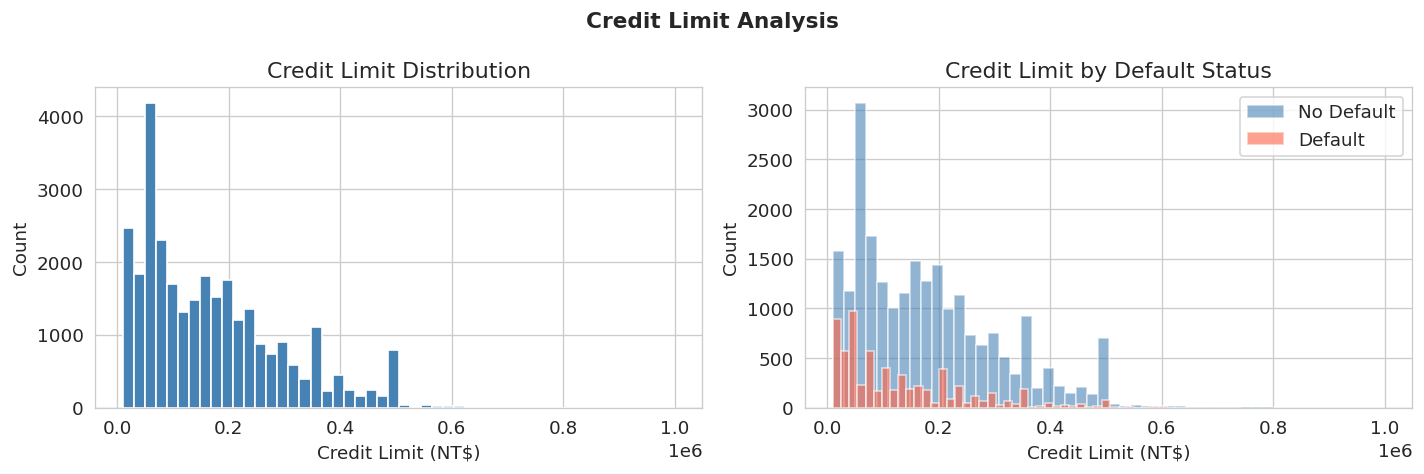

Avg credit limit (No Default): NT$178,100
Avg credit limit (Default):    NT$130,110


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(df['LIMIT_BAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Count')

# By default status
df[df['target']==0]['LIMIT_BAL'].hist(ax=axes[1], bins=50,
                                       alpha=0.6, color='steelblue',
                                       label='No Default')
df[df['target']==1]['LIMIT_BAL'].hist(ax=axes[1], bins=50,
                                       alpha=0.6, color='tomato',
                                       label='Default')
axes[1].set_title('Credit Limit by Default Status')
axes[1].set_xlabel('Credit Limit (NT$)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Credit Limit Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/03_credit_limit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg credit limit (No Default): NT${df[df['target']==0]['LIMIT_BAL'].mean():,.0f}")
print(f"Avg credit limit (Default):    NT${df[df['target']==1]['LIMIT_BAL'].mean():,.0f}")

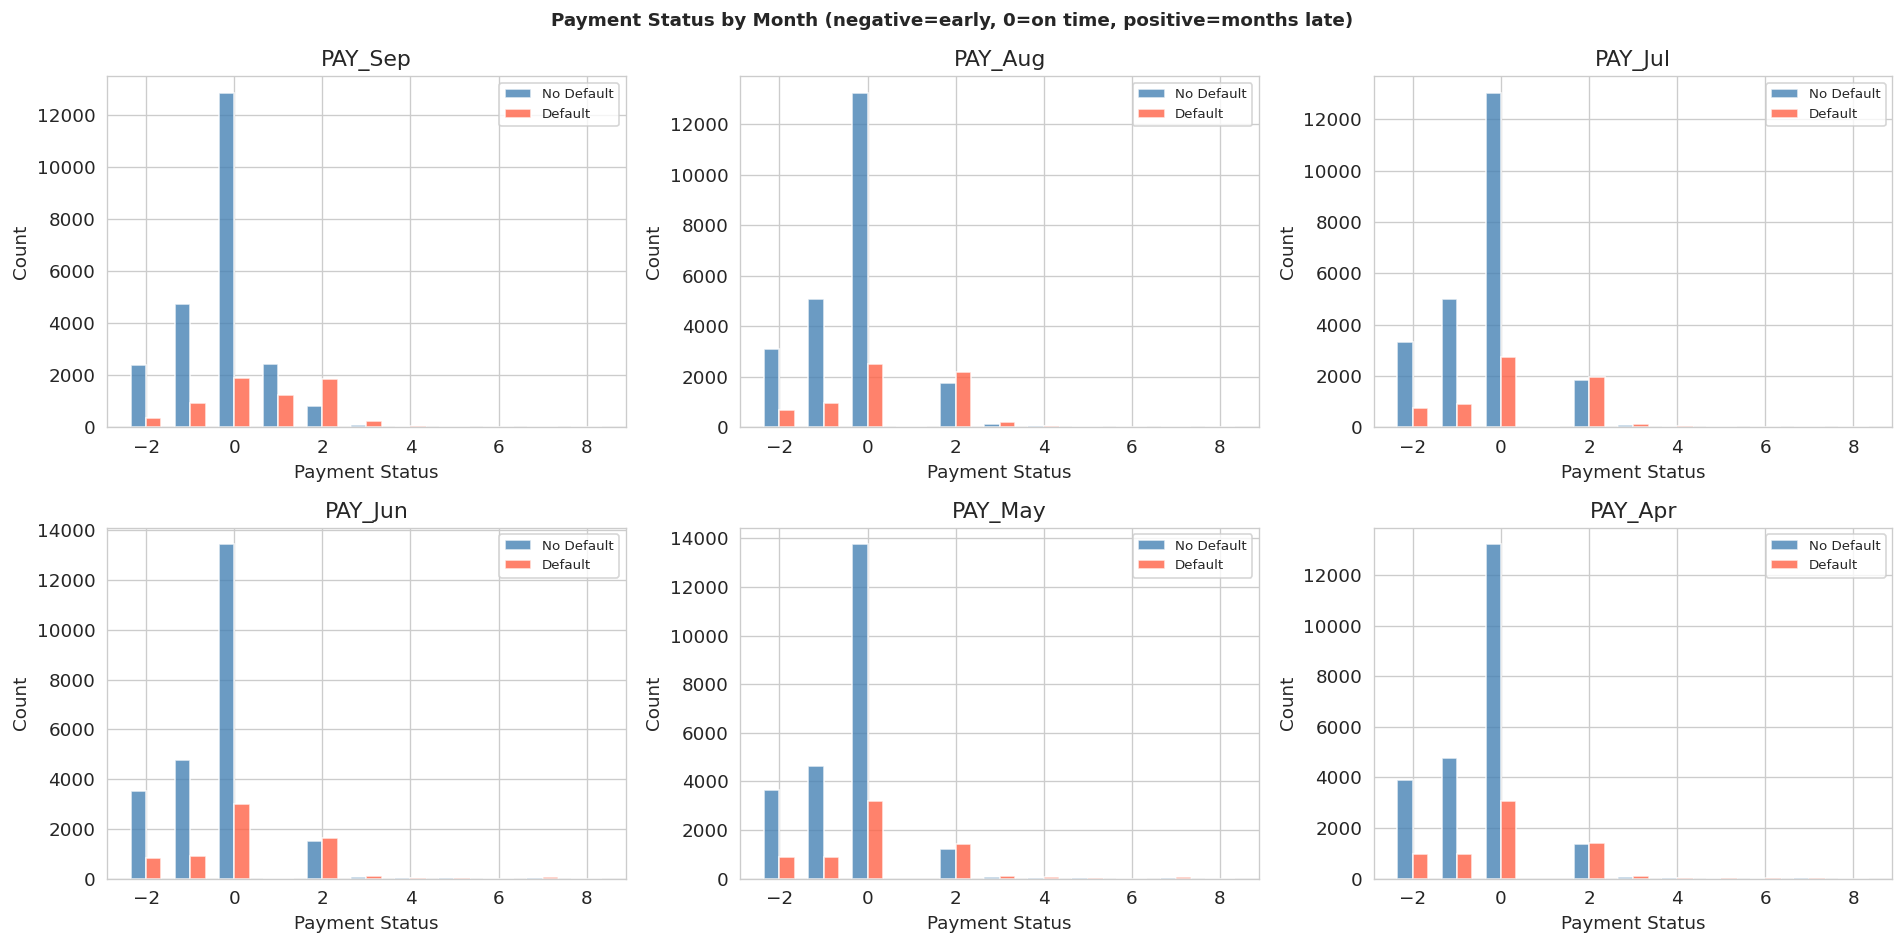

In [13]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

months = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']

for i, (col, month) in enumerate(zip(pay_cols, months)):
    default_counts    = df[df['target']==1][col].value_counts().sort_index()
    no_default_counts = df[df['target']==0][col].value_counts().sort_index()

    x = sorted(df[col].unique())
    width = 0.35
    axes[i].bar([v - width/2 for v in x],
                [no_default_counts.get(v, 0) for v in x],
                width, label='No Default', color='steelblue', alpha=0.8)
    axes[i].bar([v + width/2 for v in x],
                [default_counts.get(v, 0) for v in x],
                width, label='Default', color='tomato', alpha=0.8)
    axes[i].set_title(f'PAY_{month}')
    axes[i].set_xlabel('Payment Status')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Payment Status by Month (negative=early, 0=on time, positive=months late)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/04_payment_status.png', dpi=150, bbox_inches='tight')
plt.show()

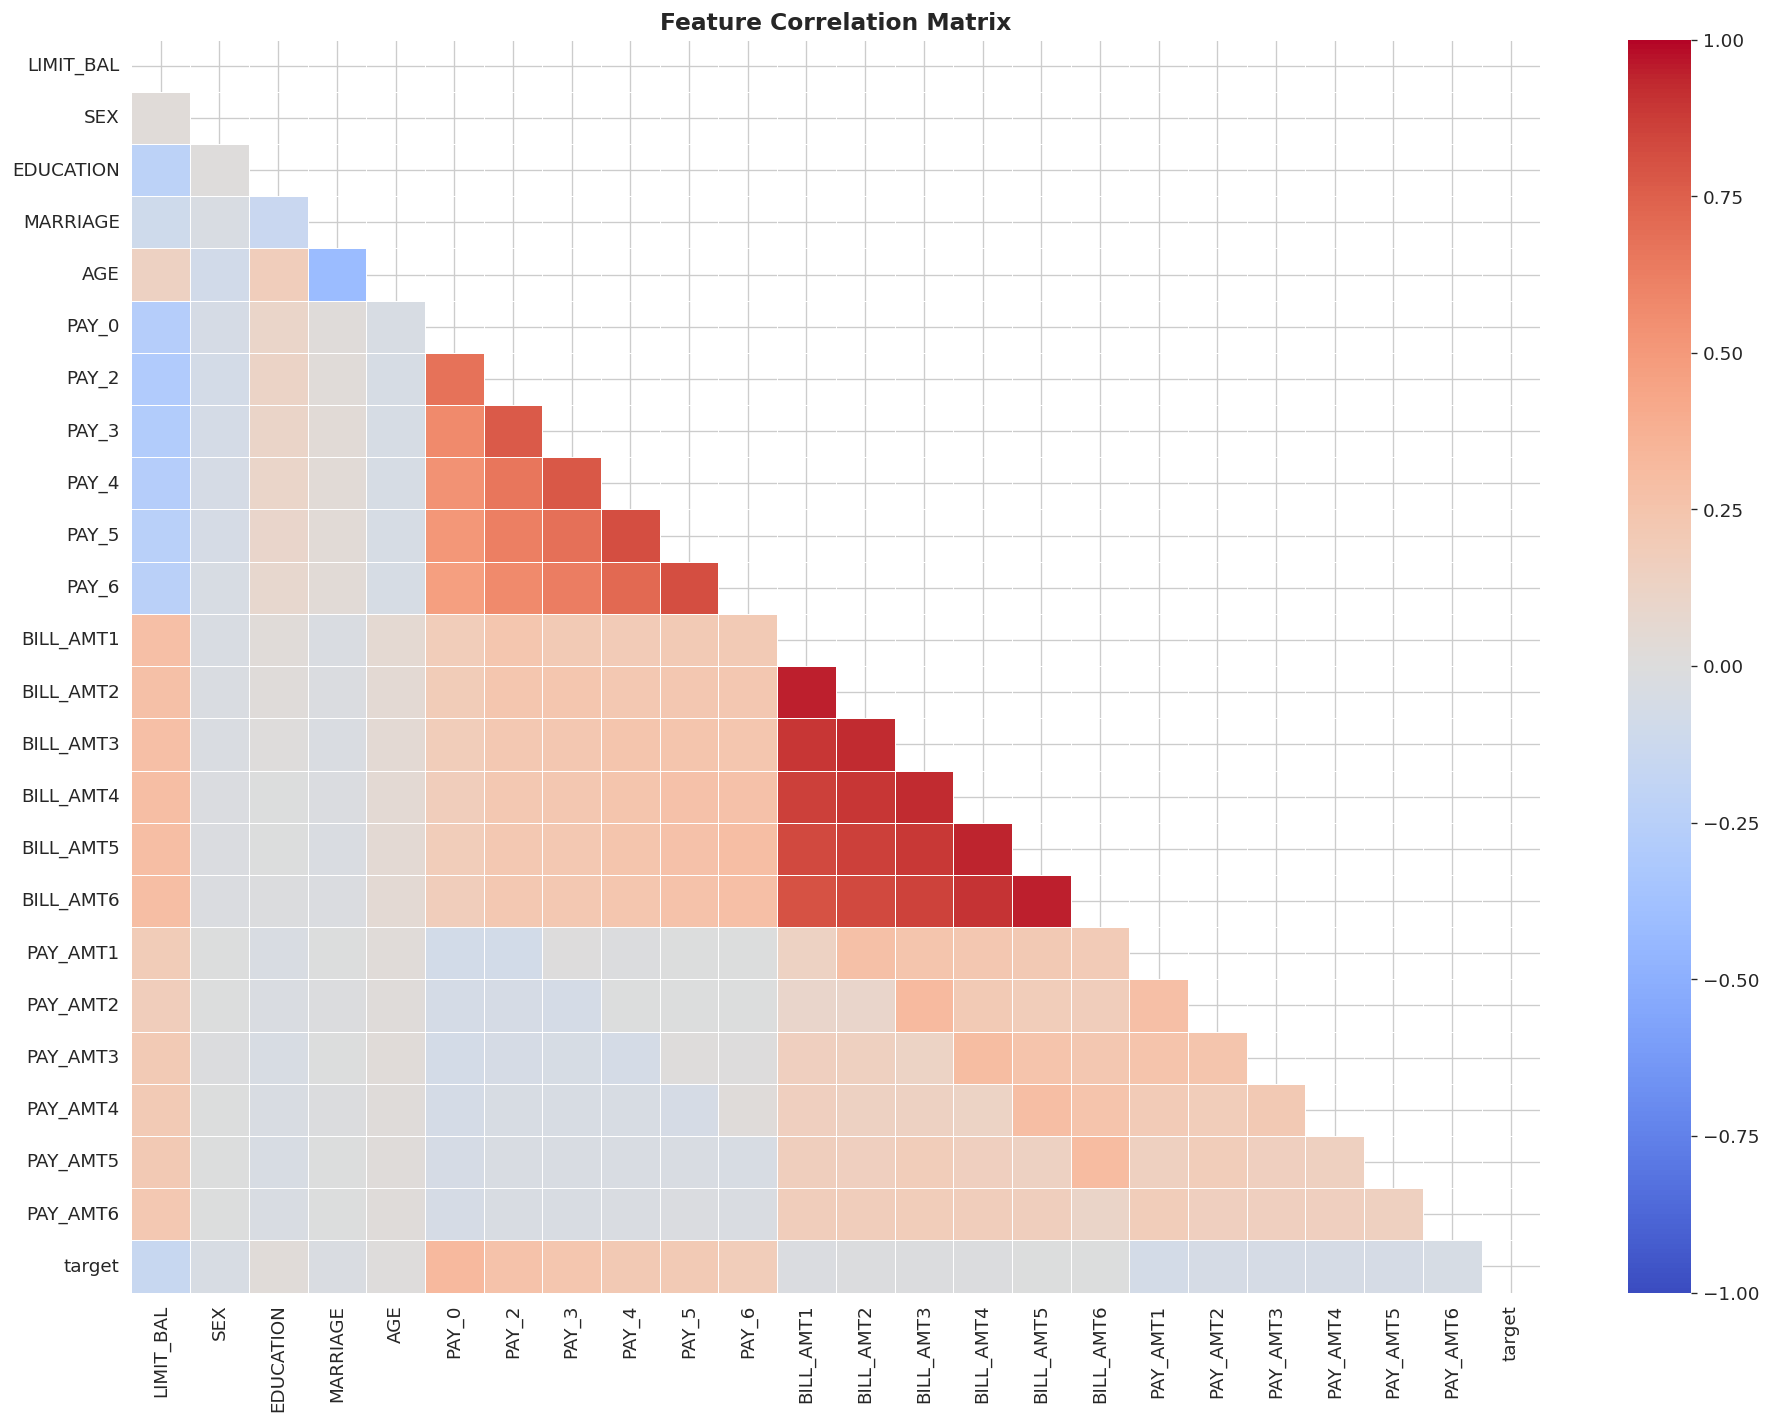

=== Top 10 Features Correlated with Default ===
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL    0.154
PAY_AMT1     0.073
PAY_AMT2     0.059
PAY_AMT4     0.057
Name: target, dtype: float64


In [14]:
plt.figure(figsize=(16, 12))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr,
            mask=mask,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
print("=== Top 10 Features Correlated with Default ===")
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.head(10).round(3))

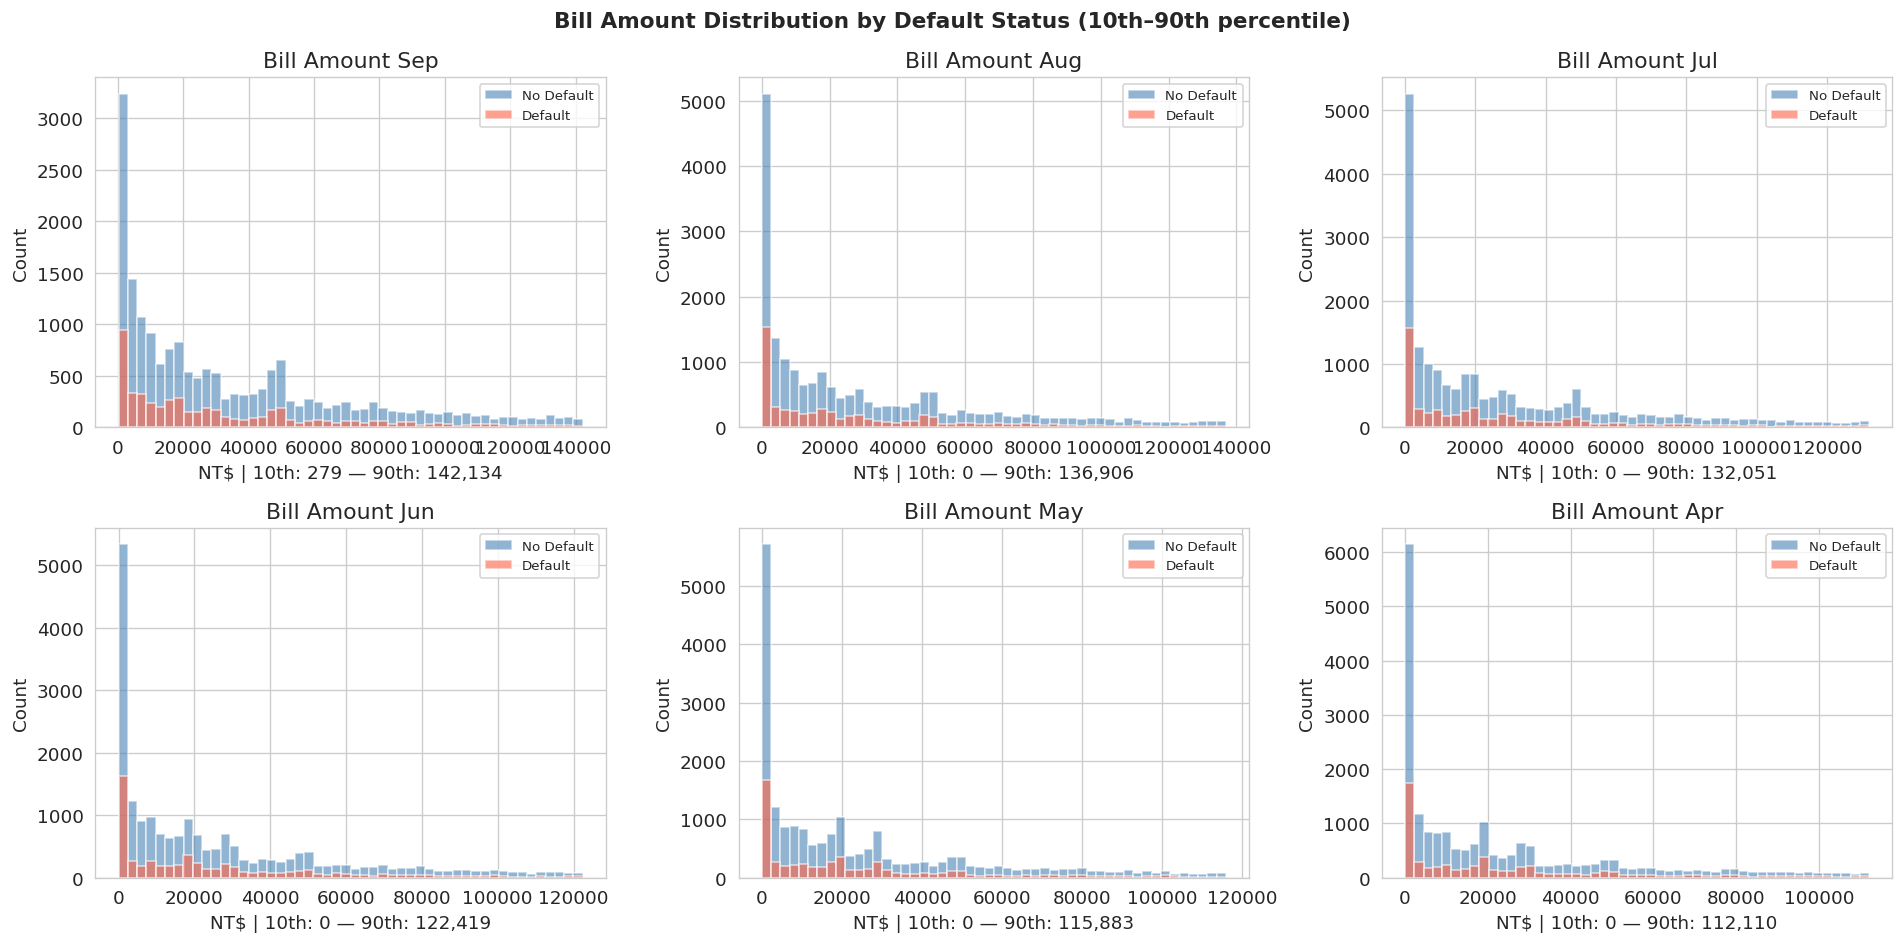

In [22]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
months    = ['Sep','Aug','Jul','Jun','May','Apr']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, month) in enumerate(zip(bill_cols, months)):
    # Clip between 10th and 90th percentile for visualization only
    p10 = df[col].quantile(0.10)
    p90 = df[col].quantile(0.90)
    data_clipped = df[(df[col] >= p10) & (df[col] <= p90)]

    data_clipped[data_clipped['target']==0][col].hist(
        ax=axes[i], bins=50, alpha=0.6,
        color='steelblue', label='No Default')
    data_clipped[data_clipped['target']==1][col].hist(
        ax=axes[i], bins=50, alpha=0.6,
        color='tomato', label='Default')

    axes[i].set_title(f'Bill Amount {month}')
    axes[i].set_xlabel(f'NT$ | 10th: {p10:,.0f} — 90th: {p90:,.0f}')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Bill Amount Distribution by Default Status (10th–90th percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/06_bill_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

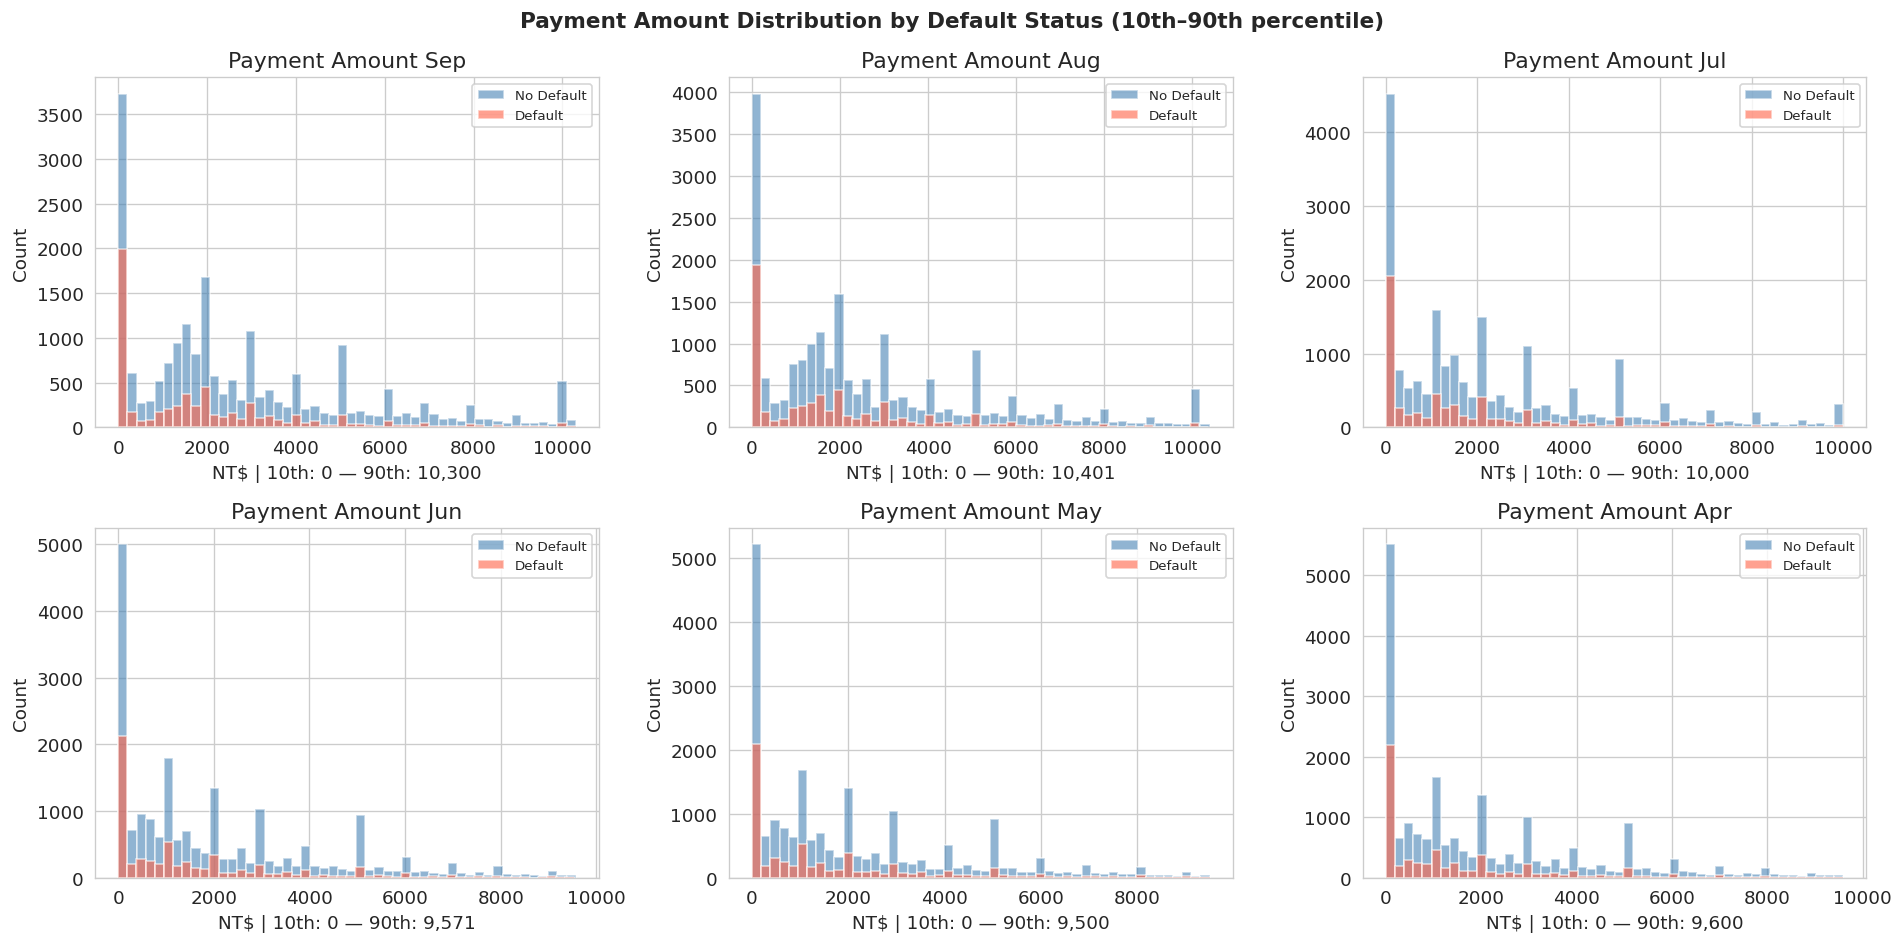

In [23]:
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
months       = ['Sep','Aug','Jul','Jun','May','Apr']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, month) in enumerate(zip(pay_amt_cols, months)):
    # Clip between 10th and 90th percentile for visualization only
    p10 = df[col].quantile(0.10)
    p90 = df[col].quantile(0.90)
    data_clipped = df[(df[col] >= p10) & (df[col] <= p90)]

    data_clipped[data_clipped['target']==0][col].hist(
        ax=axes[i], bins=50, alpha=0.6,
        color='steelblue', label='No Default')
    data_clipped[data_clipped['target']==1][col].hist(
        ax=axes[i], bins=50, alpha=0.6,
        color='tomato', label='Default')

    axes[i].set_title(f'Payment Amount {month}')
    axes[i].set_xlabel(f'NT$ | 10th: {p10:,.0f} — 90th: {p90:,.0f}')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Payment Amount Distribution by Default Status (10th–90th percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/07_payment_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

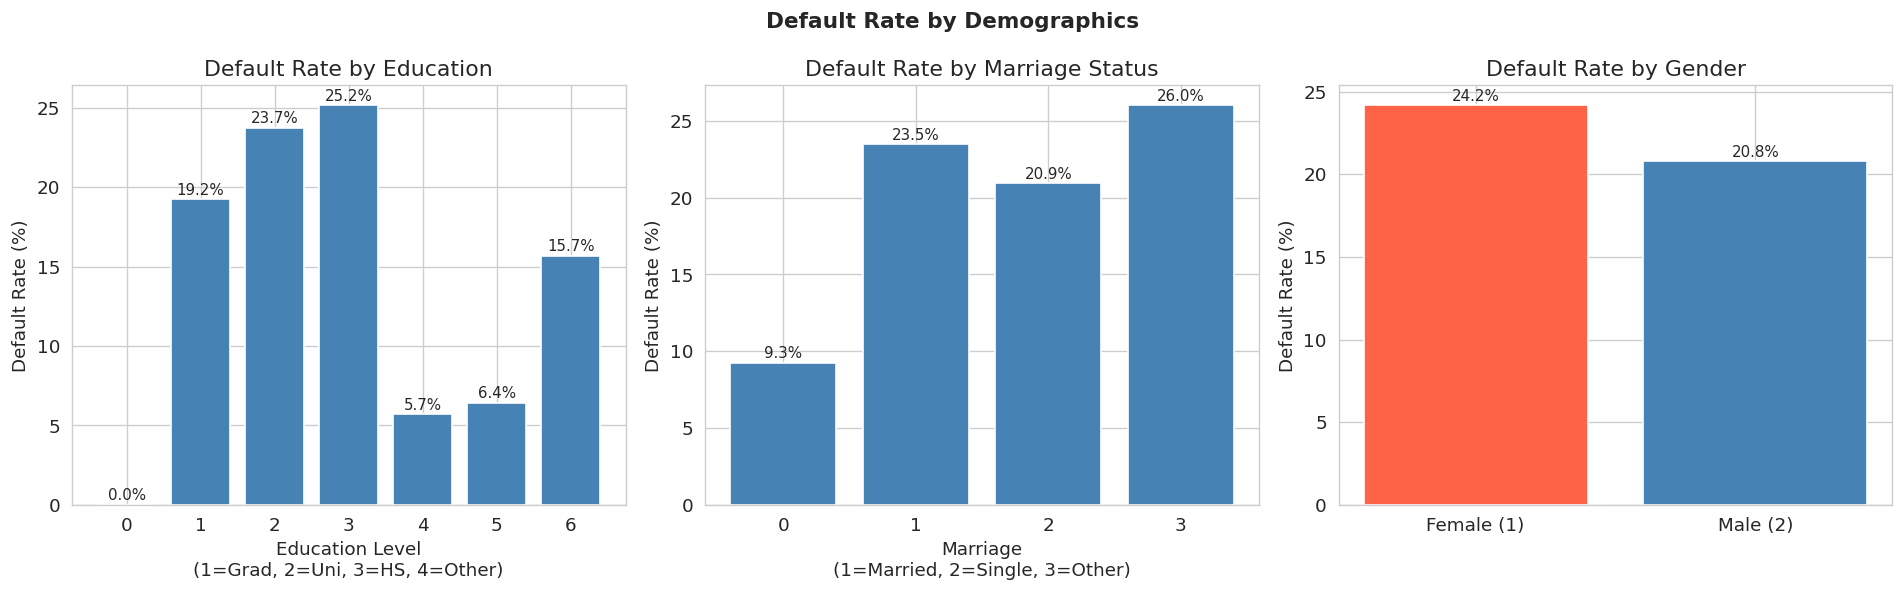

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Education
edu_default = df.groupby('EDUCATION')['target'].mean() * 100
axes[0].bar(edu_default.index.astype(str), edu_default.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by Education')
axes[0].set_xlabel('Education Level\n(1=Grad, 2=Uni, 3=HS, 4=Other)')
axes[0].set_ylabel('Default Rate (%)')
for i, v in enumerate(edu_default.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# By Marriage
mar_default = df.groupby('MARRIAGE')['target'].mean() * 100
axes[1].bar(mar_default.index.astype(str), mar_default.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Marriage Status')
axes[1].set_xlabel('Marriage\n(1=Married, 2=Single, 3=Other)')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(mar_default.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# By Sex
sex_default = df.groupby('SEX')['target'].mean() * 100
axes[2].bar(['Female (1)', 'Male (2)'],
            [sex_default[1], sex_default[2]],
            color=['tomato', 'steelblue'], edgecolor='white')
axes[2].set_title('Default Rate by Gender')
axes[2].set_ylabel('Default Rate (%)')
for i, v in enumerate([sex_default[1], sex_default[2]]):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Default Rate by Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/08_default_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 EDA Key Findings

### 1. Class Imbalance
- **22.1% default rate** (6,636 defaulters vs 23,364 non-defaulters)
- Imbalance ratio ~3.5:1
- Requires resampling strategy → will use **NearMiss undersampling**

### 2. Payment Status (Strongest Predictor)
- Customers paying **2+ months late in September** are highest default risk
- Early/on-time payers (value ≤ 0) are strongly associated with no default
- **Recent months matter more** than older months (PAY_Sep > PAY_Apr in separation power)

### 3. Credit Limit
- Non-defaulters have **significantly higher average credit limits**
- Low credit limit customers are disproportionately represented in defaults
- Suggests credit limit is a proxy for financial trustworthiness

### 4. Payment Amounts
- Both groups are **heavily right-skewed** (most people pay small amounts)
- Defaulters consistently pay **lower amounts** across all 6 months
- Extreme outliers exist (some payments > NT$500,000)
- Raw payment amount alone is weak → ratio features (pay/bill) will be more useful

### 5. Demographics
- **Education:** Graduate students default less than high school educated
- **Gender:** Small difference between male and female default rates
- **Marriage:** Married customers show slightly higher default rate than single

### 6. Bill Amounts
- Similar distributions between defaulters and non-defaulters
- Raw bill amount is a **weak standalone predictor**
- Needs to be combined with credit limit → utilization ratio

---

### 🔑 Implications for Modeling
| Observation | Action |
|---|---|
| 22% default rate | NearMiss undersampling |
| Payment status is strongest signal | Engineer `late_pay_count`, `max_pay_status` |
| Recency matters | Engineer `pay_trend`, `pay_trend_long` |
| Raw amounts weak | Engineer `util_ratio`, `pay_ratio`, `bill_to_pay` |
| Outliers in payment amounts | Clip at 99th percentile before training |